In [52]:
# Importing the Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pandas import DataFrame
from pandas.plotting import scatter_matrix
from matplotlib import rcParams
import plotly.graph_objects as go
import plotly.express as px
from plotly.colors import n_colors
import pandas_profiling
%matplotlib.inline
from matplotlib import rc
import scipy.stats
from scipy.stats.msats import winsorize

UsageError: Line magic function `%matplotlib.inline` not found.


In [54]:
# Loading the Data
data = pd.read_csv('Life Expectancy Data.csv')

In [56]:
# Analyse the Top 5 rows of the Data
data.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [58]:
# Now let’s have a look at some statistics from the data
data.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [60]:
data.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

In [62]:
# Now let’s change the names of all the columns to make them look uniform
data.rename(columns = {" BMI " :"BMI", 
                                  "Life expectancy ": "Life_expectancy",
                                  "Adult Mortality":"Adult_mortality",
                                  "infant deaths":"Infant_deaths",
                                  "percentage expenditure":"Percentage_expenditure",
                                  "Hepatitis B":"HepatitisB",
                                  "Measles ":"Measles",
                                  "under-five deaths ": "Under_five_deaths",
                                  "Total expenditure":"Total_expenditure",
                                  "Diphtheria ": "Diphtheria",
                                  " thinness  1-19 years":"Thinness_1-19_years",
                                  " thinness 5-9 years":"Thinness_5-9_years",
                                  " HIV/AIDS":"HIV/AIDS",
                                  "Income composition of resources":"Income_composition_of_resources"}, inplace = True)

#### Data Cleaning

In [65]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life_expectancy                  2928 non-null   float64
 4   Adult_mortality                  2928 non-null   float64
 5   Infant_deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   Percentage_expenditure           2938 non-null   float64
 8   HepatitisB                       2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  Under_five_deaths                2938 non-null   int64  
 12  Polio               

In [67]:
# Now let's check for any null values in the data
data.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life_expectancy                     10
Adult_mortality                     10
Infant_deaths                        0
Alcohol                            194
Percentage_expenditure               0
HepatitisB                         553
Measles                              0
BMI                                 34
Under_five_deaths                    0
Polio                               19
Total_expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Population                         652
Thinness_1-19_years                 34
Thinness_5-9_years                  34
Income_composition_of_resources    167
Schooling                          163
dtype: int64

##### There are many columns with null values, but the number of missing values is not large enough to remove the columns. So imputing missing values would be a good idea. We also know that all columns with missing values are numeric continuous variables.

In [70]:
# Filling in the missing values with a central tendency average would not be a good idea due to the outliers. We can also fill it with the median
data.reset_index(drop=True, inplace=True)

# Apply interpolation and flatten the result
data = data.groupby('Country', group_keys=False).apply(lambda group: group.interpolate(method='linear'))

# Fill remaining missing values with median per year
imputed_data = []
for year in data['Year'].unique():
    year_data = data[data['Year'] == year].copy()
    for col in year_data.columns[4:]:  # Assuming numeric columns start from 5th column
        if year_data[col].isnull().any():
            median_value = year_data[col].dropna().median()
            year_data[col].fillna(median_value, inplace=True)
    imputed_data.append(year_data)

# Combine all years back into a single DataFrame
data = pd.concat(imputed_data).reset_index(drop=True)



C:\Users\irt\AppData\Local\Temp\ipykernel_20648\3072206638.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data = data.groupby('Country', group_keys=False).apply(lambda group: group.interpolate(method='linear'))
C:\Users\irt\AppData\Local\Temp\ipykernel_20648\3072206638.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data = data.groupby('Country', group_keys=False).apply(lambda group: group.interpolate(method='linear'))
C:\Users\irt\AppData\Local\Temp\ipykernel_20648\3072206638.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data = data.groupby('Country', group_keys=False).apply(lambda group: group.inte

In [72]:
data

,Country,Year,Status,Life_expectancy,Adult_mortality,Infant_deaths,Alcohol,Percentage_expenditure,HepatitisB,Measles,...,Polio,Total_expenditure,Diphtheria,HIV/AIDS,GDP,Population,Thinness_1-19_years,Thinness_5-9_years,Income_composition_of_resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.010,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Albania,2015,Developing,77.8,74.0,0,4.600,364.975229,99.0,0,...,99.0,6.00,99.0,0.1,3954.227830,28873.0,1.2,1.3,0.762,14.2
2,Algeria,2015,Developing,75.6,19.0,21,5.285,0.000000,95.0,63,...,95.0,7.08,95.0,0.1,4132.762920,39871528.0,6.0,5.8,0.743,14.4
3,Angola,2015,Developing,52.4,335.0,66,5.285,0.000000,64.0,118,...,7.0,7.08,64.0,1.9,3695.793748,2785935.0,8.3,8.2,0.531,11.4
4,Antigua and Barbuda,2015,Developing,76.4,13.0,0,5.285,0.000000,99.0,0,...,86.0,7.08,99.0,0.2,13566.954100,2076086.0,3.3,3.3,0.784,13.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Venezuela (Bolivarian Republic of),2000,Developing,72.5,168.0,11,8.010,0.000000,5.0,22,...,86.0,4.91,77.0,0.1,828.989862,1243229.0,1.8,1.7,0.670,10.6
2934,Viet Nam,2000,Developing,73.4,139.0,33,1.600,0.000000,78.0,16512,...,96.0,4.89,96.0,0.1,828.989862,1243229.0,15.8,16.4,0.569,10.4
2935,Yemen,2000,Developing,68.0,252.0,48,0.070,0.000000,14.0,0,...,74.0,4.14,74.0,0.1,828.989862,1243229.0,14.1,14.1,0.436,7.7
2936,Zambia,2000,Developing,43.8,614.0,44,2.620,45.616880,82.0,30930,...,85.0,7.16,85.0,18.7,341.955625,1531221.0,7.5,7.5,0.418,9.6


#### Removing Outliers

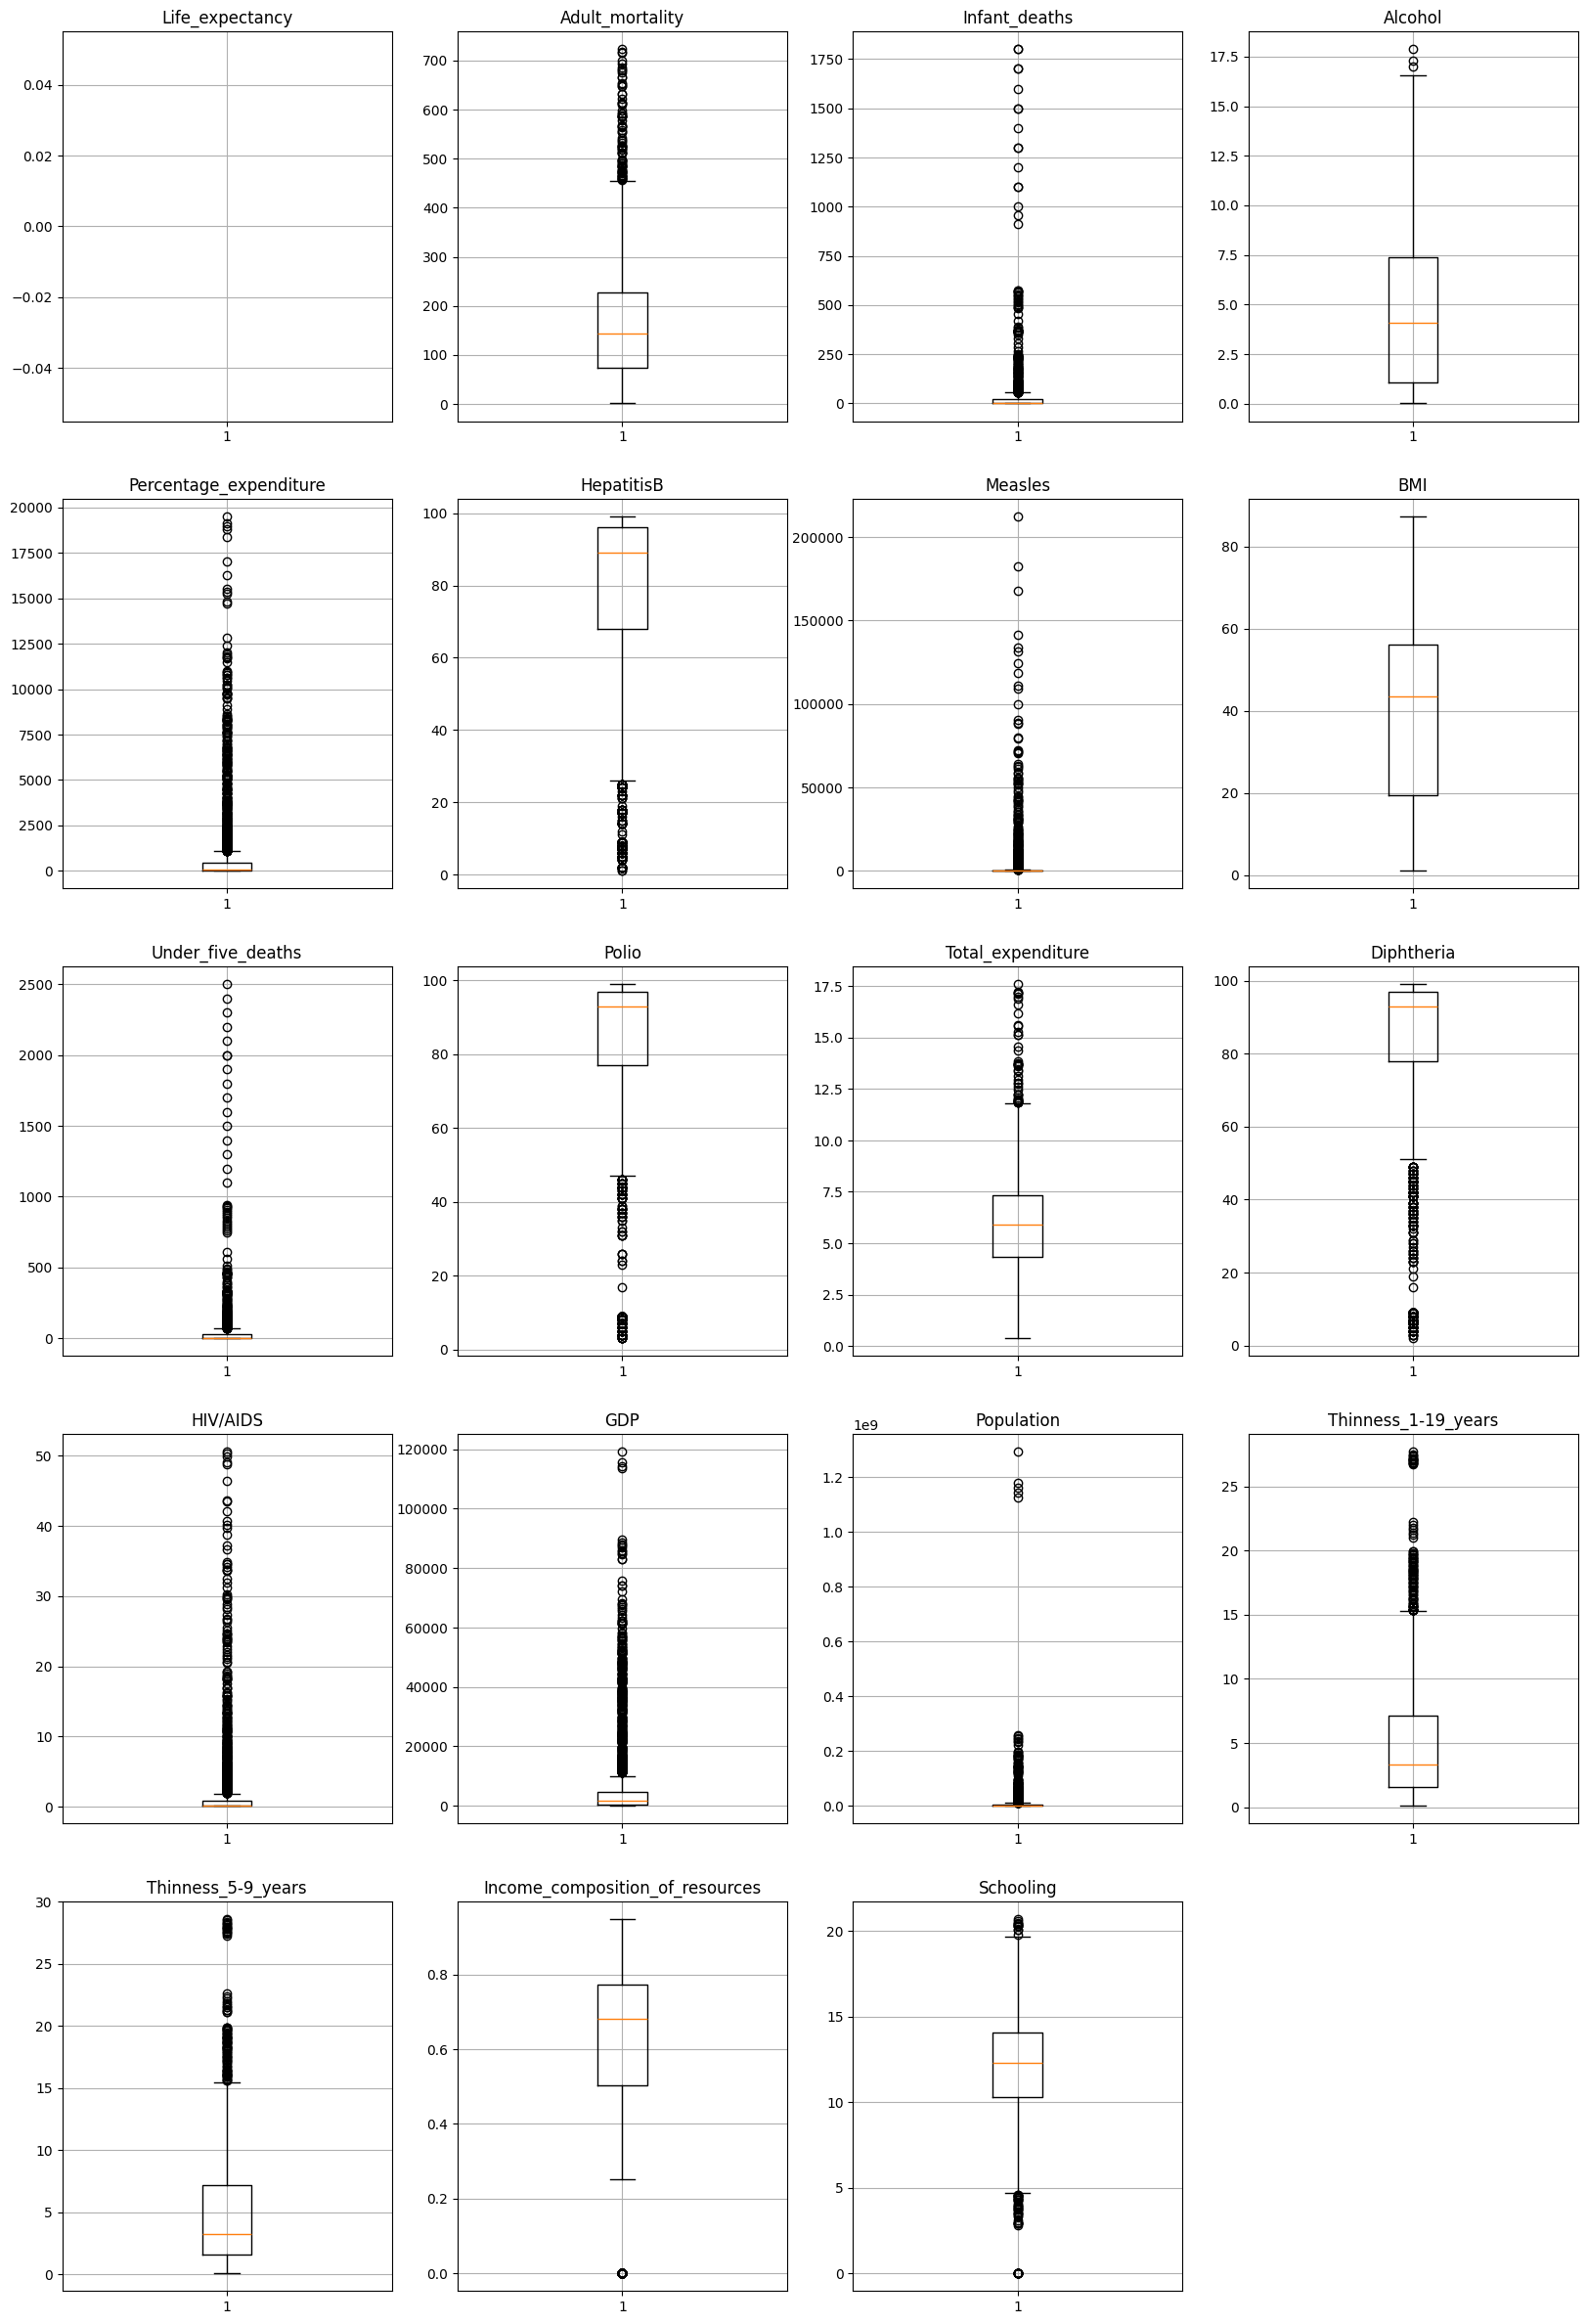

In [75]:
col_dict = {'Life_expectancy':1,'Adult_mortality':2,'Infant_deaths':3,'Alcohol':4,'Percentage_expenditure':5,'HepatitisB':6,'Measles':7,'BMI':8,'Under_five_deaths':9,'Polio':10,'Total_expenditure':11,'Diphtheria':12,'HIV/AIDS':13,'GDP':14,'Population':15,'Thinness_1-19_years':16,'Thinness_5-9_years':17,'Income_composition_of_resources':18,'Schooling':19}

# Detect outliers in each variable using box plots.
fig = plt.figure(figsize=(20,30))

for variable,i in col_dict.items():
                     plt.subplot(5,4,i)
                     plt.boxplot(data[variable])
                     plt.title(variable)
                     plt.grid(True)
    
plt.show()

##### Infant_Deaths represents several infant deaths per 1,000 population. That is why the number beyond 1000 is unrealistic. We will therefore remove them as outliers. The same is true for measles and deaths under five, as both are a number per 1,000 population.

As we can see, some countries spend up to 20,000% of their GDP on health. Most countries spend less than 2,500% of their GDP on health. Since the values ​​are very important in the Expenditure_Percentage, GDP, and Population columns, it is better to take a logarithmic value or use winsorization if necessary.

The BMI values ​​are very unrealistic because the value plus 40 is considered extreme obesity. The median is over 40 and some countries have an average of around 60 which is not possible. We can delete this whole column.

C:\Users\irt\anaconda3\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


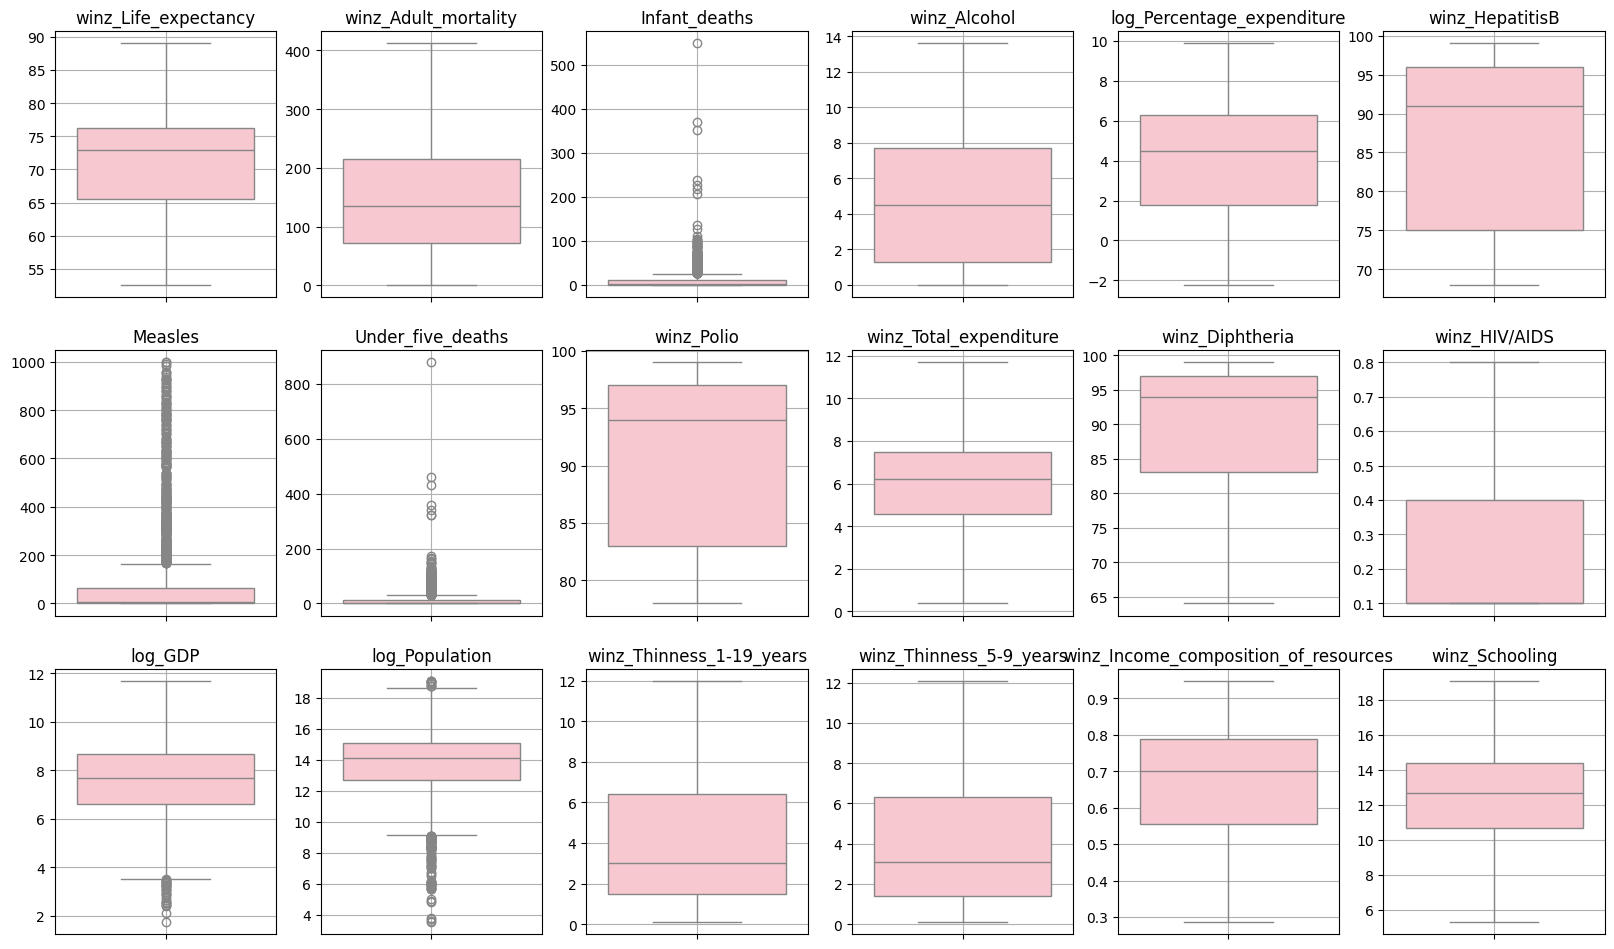

In [84]:
data = data[data['Infant_deaths'] < 1001]
data = data[data['Measles'] < 1001]
data = data[data['Under_five_deaths'] < 1001]

data['log_Percentage_expenditure'] = np.log(data['Percentage_expenditure'])
data['log_Population'] = np.log(data['Population'])
data['log_GDP'] = np.log(data['GDP'])
data = data.replace([np.inf, -np.inf], 0)
data['log_Percentage_expenditure']

data['winz_Life_expectancy'] = winsorize(data['Life_expectancy'], (0.05,0))
data['winz_Adult_mortality'] = winsorize(data['Adult_mortality'], (0,0.04))
data['winz_Alcohol'] = winsorize(data['Alcohol'], (0.0,0.01))
data['winz_HepatitisB'] = winsorize(data['HepatitisB'], (0.20,0.0))
data['winz_Polio'] = winsorize(data['Polio'], (0.20,0.0))
data['winz_Total_expenditure'] = winsorize(data['Total_expenditure'], (0.0,0.02))
data['winz_Diphtheria'] = winsorize(data['Diphtheria'], (0.11,0.0))
data['winz_HIV/AIDS'] = winsorize(data['HIV/AIDS'], (0.0,0.21))
data['winz_Thinness_1-19_years'] = winsorize(data['Thinness_1-19_years'], (0.0,0.04))
data['winz_Thinness_5-9_years'] = winsorize(data['Thinness_5-9_years'], (0.0,0.04))
data['winz_Income_composition_of_resources'] = winsorize(data['Income_composition_of_resources'], (0.05,0.0))
data['winz_Schooling'] = winsorize(data['Schooling'], (0.03,0.01))

col_dict_winz = {'winz_Life_expectancy':1,'winz_Adult_mortality':2,'Infant_deaths':3,'winz_Alcohol':4,
            'log_Percentage_expenditure':5,'winz_HepatitisB':6,'Measles':7,'Under_five_deaths':8,'winz_Polio':9,
            'winz_Total_expenditure':10,'winz_Diphtheria':11,'winz_HIV/AIDS':12,'log_GDP':13,'log_Population':14,
            'winz_Thinness_1-19_years':15,'winz_Thinness_5-9_years':16,'winz_Income_composition_of_resources':17,
            'winz_Schooling':18}


fig = plt.figure(figsize=(20,20))
for variable,i in col_dict_winz.items():
                     plt.subplot(5,6,i)
                     sns.boxplot(y = data[variable], color = "pink")
                     plt.title(variable)
                     plt.ylabel('')
                     
                     plt.grid(True)
    
plt.show()

#### Life Expectancy Analysis


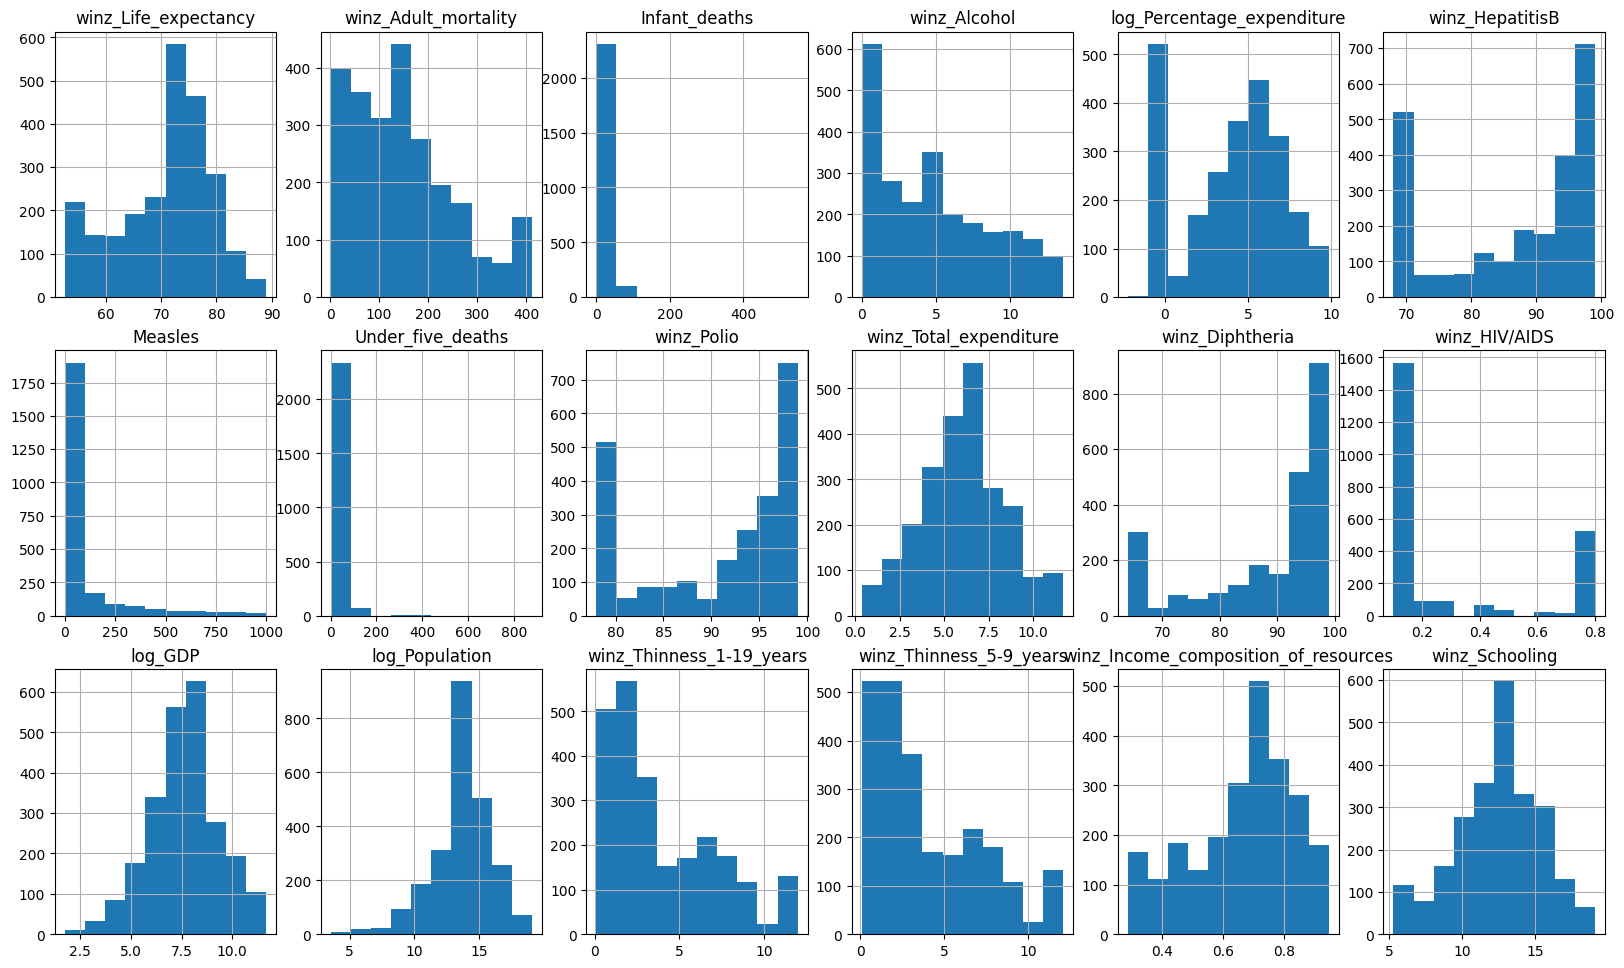

In [89]:
fig = plt.figure(figsize=(20,20))
for variable,i in col_dict_winz.items():
                     plt.subplot(5,6,i)
                     plt.hist(data[variable])
                     plt.title(variable)
                     plt.ylabel('')
                     
                     plt.grid(True)
    
plt.show()

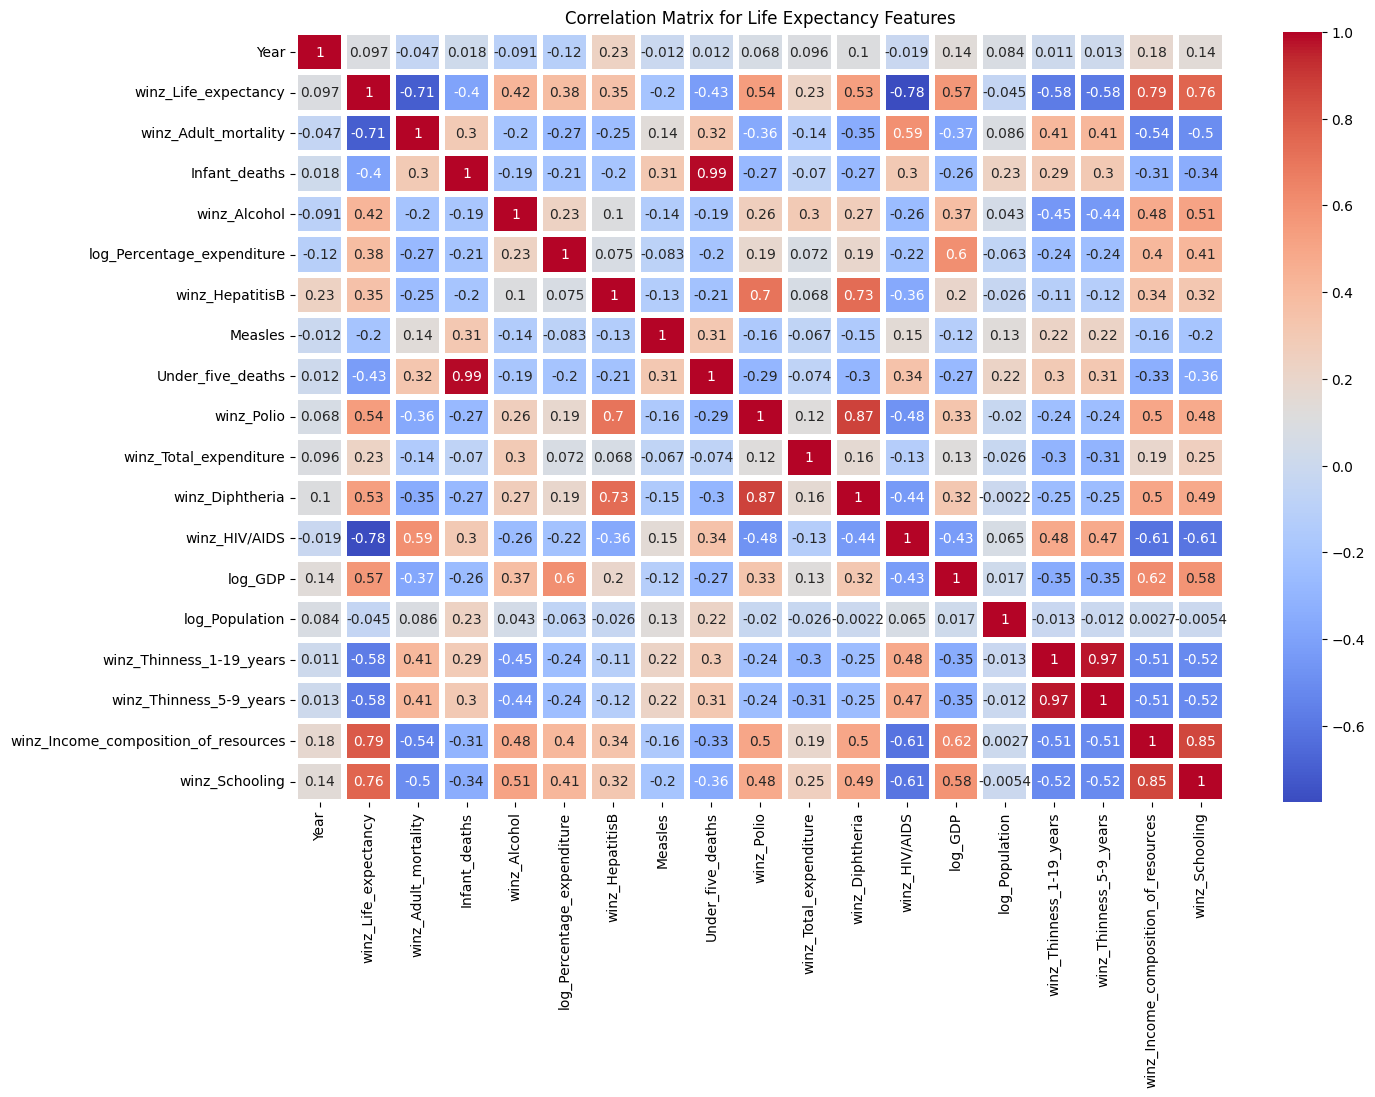

In [93]:
plt.figure(figsize=(15, 10))

# Compute correlation on only numeric columns
numeric_life_exp = life_exp.select_dtypes(include=[np.number])
sns.heatmap(numeric_life_exp.corr(), annot=True, linewidths=4, cmap="coolwarm")

plt.title("Correlation Matrix for Life Expectancy Features")
plt.show()


##### Observations from the above correlation:

1. Adult_mortality has a negative relationship with education, the composition of resource income, and a positive relationship with HIV / AIDS.
2. Infant_deaths and Under_five_deaths have a strong positive relationship.
3. Schooling and alcohol have a positive relationship.
4. Percentage expenditure has a positive relationship with education, the composition of resource income, GDP and life expectancy.
5. hepatitis B has a strong positive relationship with polio and diphtheria.
6. Polio also has a strong positive relationship with diphtheria, hepatitis B, and life expectancy.
7. Diphtheria has a strong positive relationship with polio and life expectancy.

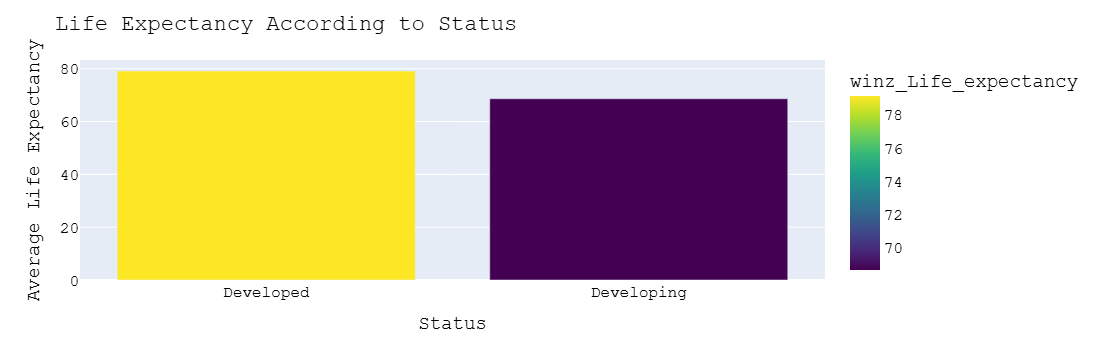

In [99]:
status_life_exp = data.groupby(by=['Status']).mean(numeric_only=True).reset_index().sort_values(
    'winz_Life_expectancy', ascending=False).reset_index(drop=True)

fig = px.bar(status_life_exp,
             x='Status',
             y='winz_Life_expectancy',
             color='winz_Life_expectancy',
             color_continuous_scale='viridis')

fig.update_layout(
    title="Life Expectancy According to Status",
    xaxis_title="Status",
    yaxis_title="Average Life Expectancy",
    font=dict(
        family="Courier New",
        size=16,
        color="black"
    )
)

fig.show()


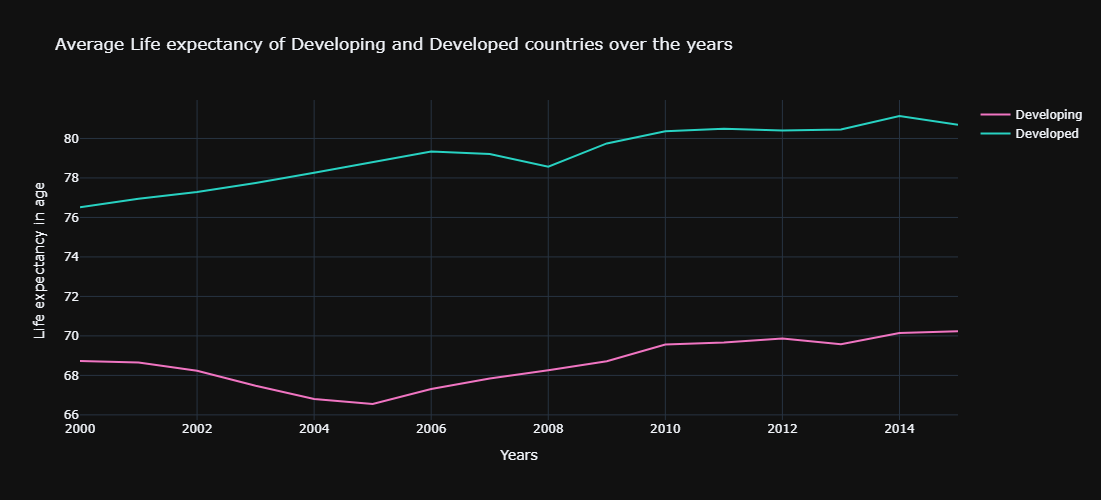

In [103]:
life_year = data.groupby(by = ['Year', 'Status']).mean(numeric_only=True).reset_index()
Developed = life_year.loc[life_year['Status'] == 'Developed',:]
Developing = life_year.loc[life_year['Status'] == 'Developing',:]
fig1 = go.Figure()
for template in ["plotly_dark"]:
    fig1.add_trace(go.Scatter(x=Developing['Year'], y=Developing['winz_Life_expectancy'],
                    mode='lines',
                    name='Developing',
                    marker_color='#f075c2'))
    fig1.add_trace(go.Scatter(x=Developed['Year'], y=Developed['winz_Life_expectancy'],
                    mode='lines',
                    name='Developed',
                    marker_color='#28d2c2'))
    fig1.update_layout(
    height=500,
    xaxis_title="Years",
    yaxis_title='Life expectancy in age',
    title_text='Average Life expectancy of Developing and Developed countries over the years',
    template=template)
fig1.show()

#### We can see from the two graphs above that developed countries have more life expectancy than in developing countries.